In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate bitsandbytes scikit-learn pandas numpy matplotlib seaborn datasets huggingface_hub

import torch
import transformers
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Transformers version:", transformers.__version__)

# Verify GPU works with a simple op
if torch.cuda.is_available():
    x = torch.randn(3, 3).cuda().half()
    y = x @ x
    print("GPU float16 test: OK")
    print("GPU:", torch.cuda.get_device_name(0))

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.4 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
Transformers version: 5.8.0.dev0
GPU float16 test: OK
GPU: Tesla T4


In [2]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
MODEL_NAME  = "Qwen/Qwen3.5-0.8B"
NOTEBOOK_ID = "qwen3.5-0.8B"

LABELS    = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]
LABEL2INT = {l: i for i, l in enumerate(LABELS)}

MAX_NEW_TOKENS = 256
TEMPERATURE    = 0.0
TOP_P          = 1.0

print("Model:", MODEL_NAME)
print("Labels:", LABELS)

Model: Qwen/Qwen3.5-0.8B
Labels: ['Ambivalent', 'Clear Reply', 'Clear Non-Reply']


In [4]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

raw = load_dataset("ailsntua/QEvasion")

train_full = raw["train"].to_pandas()
test_df    = raw["test"].to_pandas()

for df in [train_full, test_df]:
    df.columns = df.columns.str.strip().str.lower()

train_full = train_full.rename(columns={"interview_answer": "answer", "clarity_label": "label"})
test_df    = test_df.rename(columns={"interview_answer": "answer", "clarity_label": "label"})

train_full = train_full.dropna(subset=["question", "answer", "label"]).reset_index(drop=True)
test_df    = test_df.dropna(subset=["question", "answer"]).reset_index(drop=True)

# Split train_full → train_df (for few-shot selection) + val_full (for subset sampling)
train_df, val_full = train_test_split(
    train_full, test_size=0.15, random_state=SEED, stratify=train_full["label"]
)
train_df = train_df.reset_index(drop=True)
val_full = val_full.reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_full:", val_full.shape)
print("test_df: ", test_df.shape)
print("\nLabel distribution (train_df):\n", train_df["label"].value_counts())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

train_df: (2930, 20)
val_full: (518, 20)
test_df:  (308, 20)

Label distribution (train_df):
 label
Ambivalent         1734
Clear Reply         894
Clear Non-Reply     302
Name: count, dtype: int64


In [5]:
# Stratified 90-sample subset for fast evaluation (30 per class)
EVAL_N_PER_CLASS = 30

def make_stratified_subset(df, n_per_class, seed=SEED):
    subsets = []
    for label in LABELS:
        class_df = df[df["label"] == label]
        n = min(n_per_class, len(class_df))
        subsets.append(class_df.sample(n, random_state=seed))
    return pd.concat(subsets).sample(frac=1, random_state=seed).reset_index(drop=True)

val_subset = make_stratified_subset(val_full, n_per_class=EVAL_N_PER_CLASS)

print("val_subset size:", len(val_subset))
print(val_subset["label"].value_counts())

# Representativeness check
print("\nClass proportions:")
for label in LABELS:
    full_pct   = (val_full["label"] == label).mean() * 100
    subset_pct = (val_subset["label"] == label).mean() * 100
    print(f"  {label:20s}  full={full_pct:.1f}%  subset={subset_pct:.1f}%")

val_subset size: 90
label
Clear Reply        30
Ambivalent         30
Clear Non-Reply    30
Name: count, dtype: int64

Class proportions:
  Ambivalent            full=59.1%  subset=33.3%
  Clear Reply           full=30.5%  subset=33.3%
  Clear Non-Reply       full=10.4%  subset=33.3%


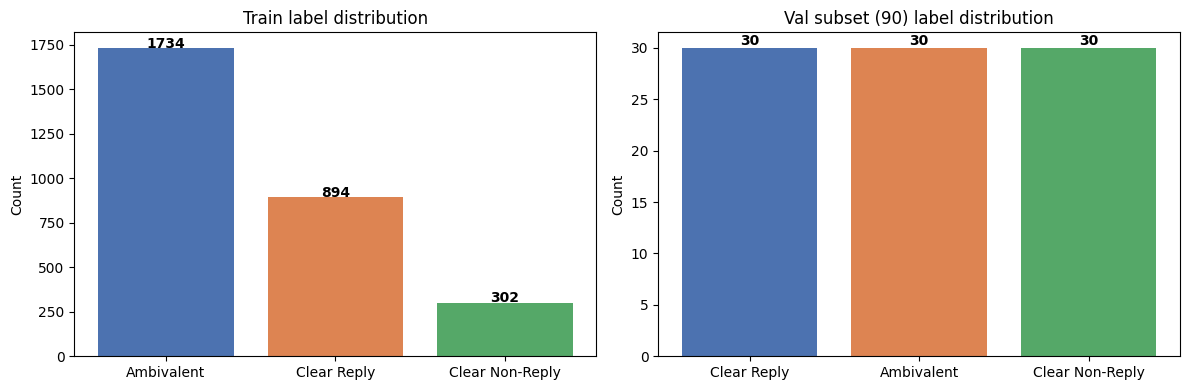

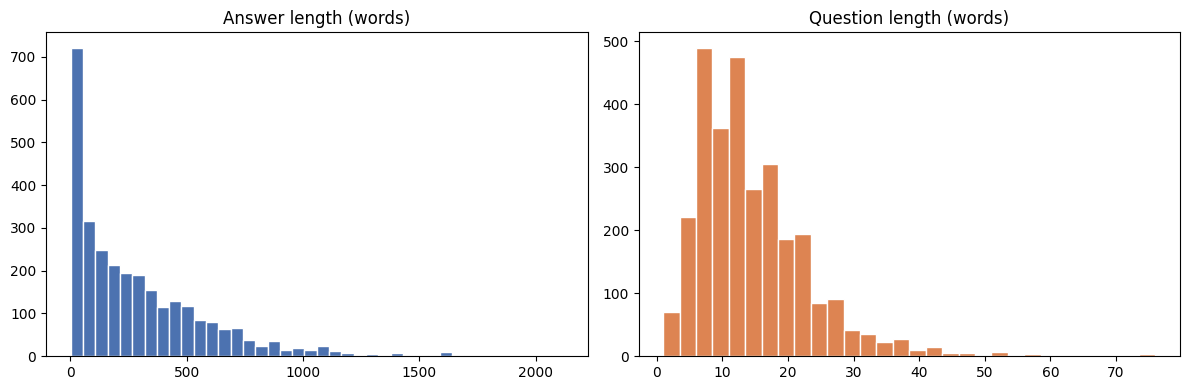

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Val subset (90)", val_subset)]):
    counts = df["label"].value_counts()
    ax.bar(counts.index, counts.values, color=["#4C72B0","#DD8452","#55A868"])
    ax.set_title(f"{name} label distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_label_distribution.png", dpi=150)
plt.show()

train_df["answer_len"]   = train_df["answer"].str.split().str.len()
train_df["question_len"] = train_df["question"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["answer_len"],   bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Answer length (words)")
axes[1].hist(train_df["question_len"], bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Question length (words)")
plt.tight_layout()
plt.savefig(f"{NOTEBOOK_ID}_length_distribution.png", dpi=150)
plt.show()

In [7]:
import gc

if "model" in globals():
    del model, tokenizer
    gc.collect()

print(f"Loading {MODEL_NAME} ...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="cuda:0", 
    trust_remote_code=True,
)
model = model.to(DEVICE)
model.eval()

print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")
print("Device:", next(model.parameters()).device)
print("Chat template exists:", tokenizer.chat_template is not None)

Loading Qwen/Qwen3.5-0.8B ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Parameters: 752.393024 M
Device: cuda:0
Chat template exists: True


In [8]:
# # FIND GOOD FEW-SHOT EXAMPLES FROM YOUR ACTUAL TRAIN SET
# import pandas as pd
# import random
# from datasets import load_dataset
# from sklearn.model_selection import train_test_split

# SEED   = 42
# LABELS = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]

# # Reload data if not in memory
# raw      = load_dataset("ailsntua/QEvasion")
# train_df = raw["train"].to_pandas()
# test_df  = raw["test"].to_pandas()

# for df in [train_df, test_df]:
#     df.columns = df.columns.str.strip().str.lower()

# train_df = train_df.rename(columns={"interview_answer": "answer", "clarity_label": "label"})
# train_df = train_df.dropna(subset=["question", "answer", "label"]).reset_index(drop=True)

# train_df, val_subset = train_test_split(
#     train_df, test_size=0.15, random_state=SEED, stratify=train_df["label"]
# )
# train_df = train_df.reset_index(drop=True)

# # Find better few-shot examples — skip very short AND very long answers

# for label in LABELS:
#     print(f"\n{'='*60}")
#     print(f"  Label: {label}")
#     print(f"{'='*60}")
#     subset = train_df[train_df["label"] == label].copy()
#     subset["answer_len"] = subset["answer"].str.split().str.len()
#     # Filter: between 20 and 80 words — long enough to be meaningful, short enough to be clear
#     subset = subset[
#         (subset["answer_len"] >= 20) &
#         (subset["answer_len"] <= 80)
#     ].sort_values("answer_len")
#     for _, row in subset.head(5).iterrows():
#         print(f"\n  Q: {row['question']}")
#         print(f"  A: {row['answer']}")
#         print(f"  Words: {row['answer_len']}")
#         print()

In [9]:
SYSTEM_PROMPT = (
    "You are a political communication analyst. "
    "Classify the politician's answer to the question as exactly one of:\n"
    "  - Clear Reply: directly and clearly answers the question.\n"
    "  - Ambivalent: vague, partial, or evasive.\n"
    "  - Clear Non-Reply: completely avoids answering.\n"
    "Respond with ONLY the label. Nothing else."
)

SYSTEM_PROMPT_COT = (
    "You are a political communication analyst. "
    "Classify the politician's answer as one of:\n"
    "  - Clear Reply\n  - Ambivalent\n  - Clear Non-Reply\n"
    "Think step by step, then write: LABEL: <your label>"
)

def build_zero_shot_messages(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nClassification:"}
    ]

def build_few_shot_messages(question, answer, examples):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for ex in examples:
        messages.append({"role": "user",
            "content": f"Question: {ex['question']}\nAnswer: {ex['answer']}\n\nClassification:"})
        messages.append({"role": "assistant", "content": ex["label"]})
    messages.append({"role": "user",
        "content": f"Question: {question}\nAnswer: {answer}\n\nClassification:"})
    return messages

def build_cot_messages(question, answer):
    return [
        {"role": "system", "content": SYSTEM_PROMPT_COT},
        {"role": "user",   "content": f"Question: {question}\nAnswer: {answer}\n\nReasoning and label:"}
    ]

print("Prompt builders defined.")

Prompt builders defined.


In [10]:
def build_plain_prompt(messages):
    parts = []
    for msg in messages:
        if msg["role"] == "system":
            parts.append(msg["content"])
        elif msg["role"] == "user":
            parts.append(f"User: {msg['content']}")
        elif msg["role"] == "assistant":
            parts.append(f"Assistant: {msg['content']}")
    parts.append("Assistant:")
    return "\n\n".join(parts)


def generate_response(messages, max_new_tokens=15, temperature=TEMPERATURE, top_p=TOP_P):
    try:
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    except Exception:
        text = build_plain_prompt(messages)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    inputs = {k: v.to("cuda:0") for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    input_len = inputs["input_ids"].shape[1]
    new_ids   = output_ids[0][input_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


def parse_label(text):
    if not text or not text.strip():
        return "Unknown"
    # CoT: extract after LABEL:
    cot = re.search(r"LABEL\s*:\s*(.+)", text, re.IGNORECASE)
    if cot:
        text = cot.group(1)
    t = text.lower().strip()
    if "clear non-reply" in t or "non-reply" in t or "non reply" in t:
        return "Clear Non-Reply"
    if "clear reply" in t:
        return "Clear Reply"
    if "ambivalent" in t or "ambiguous" in t:
        return "Ambivalent"
    if "reply" in t:
        return "Clear Reply"
    return "Unknown"


def run_inference(df, prompt_builder, max_new_tokens=15, temperature=TEMPERATURE):
    results = []
    invalid = 0
    for _, row in df.iterrows():
        messages = prompt_builder(row["question"], row["answer"])
        raw      = generate_response(messages, max_new_tokens=max_new_tokens)
        label    = parse_label(raw)
        if label == "Unknown":
            invalid += 1
        results.append({"raw_output": raw, "predicted_label": label})
        if len(results) % 30 == 0:
            print(f"  {len(results)}/{len(df)} done | invalid: {invalid}")

    out = df.copy().reset_index(drop=True)
    out["raw_output"]      = [r["raw_output"]      for r in results]
    out["predicted_label"] = [r["predicted_label"] for r in results]
    print(f"Done. Invalid: {invalid}/{len(df)} ({100*invalid/len(df):.1f}%)")
    return out


def run_self_consistency(df, prompt_builder, n_samples=3, temperature=0.7):
    results = []
    for _, row in df.iterrows():
        messages = prompt_builder(row["question"], row["answer"])
        votes = []
        for _ in range(n_samples):
            raw   = generate_response(messages, max_new_tokens=15, temperature=temperature)
            label = parse_label(raw)
            if label != "Unknown":
                votes.append(label)
        predicted = Counter(votes).most_common(1)[0][0] if votes else "Unknown"
        results.append({"predicted_label": predicted, "votes": votes})
        if len(results) % 30 == 0:
            print(f"  {len(results)}/{len(df)} done")

    out = df.copy().reset_index(drop=True)
    out["predicted_label"] = [r["predicted_label"] for r in results]
    out["votes"]           = [r["votes"]           for r in results]
    return out

print("Inference engine ready.")

Inference engine ready.


In [11]:
def evaluate(df, strategy_name):
    valid   = df[df["predicted_label"] != "Unknown"].copy()
    n_inv   = (df["predicted_label"] == "Unknown").sum()
    y_true  = valid["label"]
    y_pred  = valid["predicted_label"]

    acc        = accuracy_score(y_true, y_pred)
    macro_f1   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    w_f1       = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    macro_prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_rec  = recall_score(y_true, y_pred,    average="macro", zero_division=0)

    print(f"\n{'='*55}\n  {strategy_name}\n{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro F1        : {macro_f1:.4f}")
    print(f"  Weighted F1     : {w_f1:.4f}")
    print(f"  Macro Precision : {macro_prec:.4f}")
    print(f"  Macro Recall    : {macro_rec:.4f}")
    print(f"  Invalid outputs : {n_inv}/{len(df)}")
    print()
    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))

    return {
        "strategy": strategy_name, "accuracy": acc,
        "macro_f1": macro_f1, "weighted_f1": w_f1,
        "macro_precision": macro_prec, "macro_recall": macro_rec,
        "n_invalid": int(n_inv),
    }


def plot_confusion_matrix(df, title, ax):
    valid = df[df["predicted_label"] != "Unknown"]
    cm = confusion_matrix(valid["label"], valid["predicted_label"], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

print("Evaluation helpers ready.")

Evaluation helpers ready.


In [12]:
def select_best_few_shot_examples(df, n_per_class=1, seed=SEED):
    rng = random.Random(seed)
    examples = []
    for label in LABELS:
        subset = df[df["label"] == label].copy()
        subset["answer_len"] = subset["answer"].str.split().str.len()
        subset = subset[
            (subset["answer_len"] >= 20) &
            (subset["answer_len"] <= 80)
        ].sort_values("answer_len")
        pool   = subset.head(20).to_dict("records")
        chosen = rng.sample(pool, min(n_per_class, len(pool)))
        for ex in chosen:
            examples.append({
                "question": ex["question"],
                "answer":   ex["answer"],
                "label":    label
            })
    return examples

FEW_SHOT_EXAMPLES_TRAIN = select_best_few_shot_examples(train_df, n_per_class=1)

print("Few-shot examples selected:")
for ex in FEW_SHOT_EXAMPLES_TRAIN:
    print(f"\n  [{ex['label']}]")
    print(f"  Q: {ex['question'][:80]}")
    print(f"  A: {ex['answer'][:100]}")

def build_few_shot_messages_train(question, answer):
    return build_few_shot_messages(question, answer, examples=FEW_SHOT_EXAMPLES_TRAIN)

print("\nFew-shot builder ready.")

Few-shot examples selected:

  [Ambivalent]
  Q: Can you give me your timetable?
  A: Steve, what do you think? Within the next week or two, we think the States will be able to execute.

  [Clear Reply]
  Q:  What is your reaction?
  A: It's heartbreaking. It's heartbreaking, and I think that anybody who sees it knows that there's some

  [Clear Non-Reply]
  Q: Is there a transcript of your conversation, your private conversation?
  A: Mike, do they have a transcript? They probably have a rough transcript, which you can give us, if yo

Few-shot builder ready.


In [13]:
print("Inference will run on:", len(val_subset), "samples")
# Should print 90, not 518

Inference will run on: 90 samples


In [14]:
# Cell 11: Zero-shot — validation set
print("Running ZERO-SHOT inference on validation set...")
val_zs = run_inference(val_subset, build_zero_shot_messages, max_new_tokens=30)
metrics_zs = evaluate(val_zs, "Zero-Shot")

Running ZERO-SHOT inference on validation set...
  30/90 done | invalid: 5
  60/90 done | invalid: 6
  90/90 done | invalid: 9
Done. Invalid: 9/90 (10.0%)

  Zero-Shot
  Accuracy        : 0.3457
  Macro F1        : 0.3300
  Weighted F1     : 0.3333
  Macro Precision : 0.3281
  Macro Recall    : 0.3419
  Invalid outputs : 9/90

                 precision    recall  f1-score   support

     Ambivalent       0.24      0.24      0.24        25
    Clear Reply       0.30      0.21      0.25        28
Clear Non-Reply       0.44      0.57      0.50        28

       accuracy                           0.35        81
      macro avg       0.33      0.34      0.33        81
   weighted avg       0.33      0.35      0.33        81



In [15]:
# Cell 12: Few-shot — validation set
print("Running FEW-SHOT inference on validation set...")
val_fs = run_inference(val_subset, build_few_shot_messages_train, max_new_tokens=30)
metrics_fs = evaluate(val_fs, "Few-Shot (2-per-class)")

Running FEW-SHOT inference on validation set...
  30/90 done | invalid: 5
  60/90 done | invalid: 7
  90/90 done | invalid: 12
Done. Invalid: 12/90 (13.3%)

  Few-Shot (2-per-class)
  Accuracy        : 0.4359
  Macro F1        : 0.3280
  Weighted F1     : 0.3393
  Macro Precision : 0.5701
  Macro Recall    : 0.4145
  Invalid outputs : 12/90

                 precision    recall  f1-score   support

     Ambivalent       0.27      0.14      0.18        22
    Clear Reply       1.00      0.11      0.19        28
Clear Non-Reply       0.44      1.00      0.61        28

       accuracy                           0.44        78
      macro avg       0.57      0.41      0.33        78
   weighted avg       0.59      0.44      0.34        78



In [16]:
# Cell 13: Chain-of-Thought — validation set
print("Running CHAIN-OF-THOUGHT inference on validation set...")
val_cot = run_inference(val_subset, build_cot_messages, max_new_tokens=MAX_NEW_TOKENS)
metrics_cot = evaluate(val_cot, "Chain-of-Thought")

Running CHAIN-OF-THOUGHT inference on validation set...
  30/90 done | invalid: 12
  60/90 done | invalid: 20
  90/90 done | invalid: 30
Done. Invalid: 30/90 (33.3%)

  Chain-of-Thought
  Accuracy        : 0.4500
  Macro F1        : 0.3151
  Weighted F1     : 0.3276
  Macro Precision : 0.3642
  Macro Recall    : 0.4118
  Invalid outputs : 30/90

                 precision    recall  f1-score   support

     Ambivalent       0.00      0.00      0.00        20
    Clear Reply       0.43      1.00      0.60        23
Clear Non-Reply       0.67      0.24      0.35        17

       accuracy                           0.45        60
      macro avg       0.36      0.41      0.32        60
   weighted avg       0.35      0.45      0.33        60



In [17]:
# Cell 14: Self-Consistency (temperature sampling, majority vote)
N_SAMPLES = 5  # number of independent samples per instance

def run_self_consistency(df: pd.DataFrame, prompt_builder,
                          n_samples: int = N_SAMPLES, temperature: float = 0.7) -> pd.DataFrame:
    results = []
    for idx, row in df.iterrows():
        messages = prompt_builder(row["question"], row["answer"])
        votes = []
        for _ in range(n_samples):
            raw = generate_response(messages, max_new_tokens=30, temperature=temperature)
            label = parse_label(raw)
            if label != "Unknown":
                votes.append(label)

        if votes:
            predicted = Counter(votes).most_common(1)[0][0]
        else:
            predicted = "Unknown"

        results.append({"raw_votes": votes, "predicted_label": predicted})

        if (len(results)) % 20 == 0:
            print(f"  {len(results)}/{len(df)} done")

    out_df = df.copy().reset_index(drop=True)
    out_df["raw_votes"]       = [r["raw_votes"] for r in results]
    out_df["predicted_label"] = [r["predicted_label"] for r in results]
    return out_df

print("Running SELF-CONSISTENCY inference on validation set...")
val_sc = run_self_consistency(val_subset, build_zero_shot_messages, n_samples=N_SAMPLES)
metrics_sc = evaluate(val_sc, "Self-Consistency (n=5)")

Running SELF-CONSISTENCY inference on validation set...
  20/90 done
  40/90 done
  60/90 done
  80/90 done

  Self-Consistency (n=5)
  Accuracy        : 0.3457
  Macro F1        : 0.3300
  Weighted F1     : 0.3333
  Macro Precision : 0.3281
  Macro Recall    : 0.3419
  Invalid outputs : 9/90

                 precision    recall  f1-score   support

     Ambivalent       0.24      0.24      0.24        25
    Clear Reply       0.30      0.21      0.25        28
Clear Non-Reply       0.44      0.57      0.50        28

       accuracy                           0.35        81
      macro avg       0.33      0.34      0.33        81
   weighted avg       0.33      0.35      0.33        81




── Summary Table (Validation Set) ────────────────────────────
                        accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  n_invalid
strategy                                                                                         
Zero-Shot               0.345679  0.330000     0.333333         0.328148      0.341905          9
Few-Shot (2-per-class)  0.435897  0.328021     0.339267         0.570076      0.414502         12
Chain-of-Thought        0.450000  0.315076     0.327555         0.364198      0.411765         30
Self-Consistency (n=5)  0.345679  0.330000     0.333333         0.328148      0.341905          9


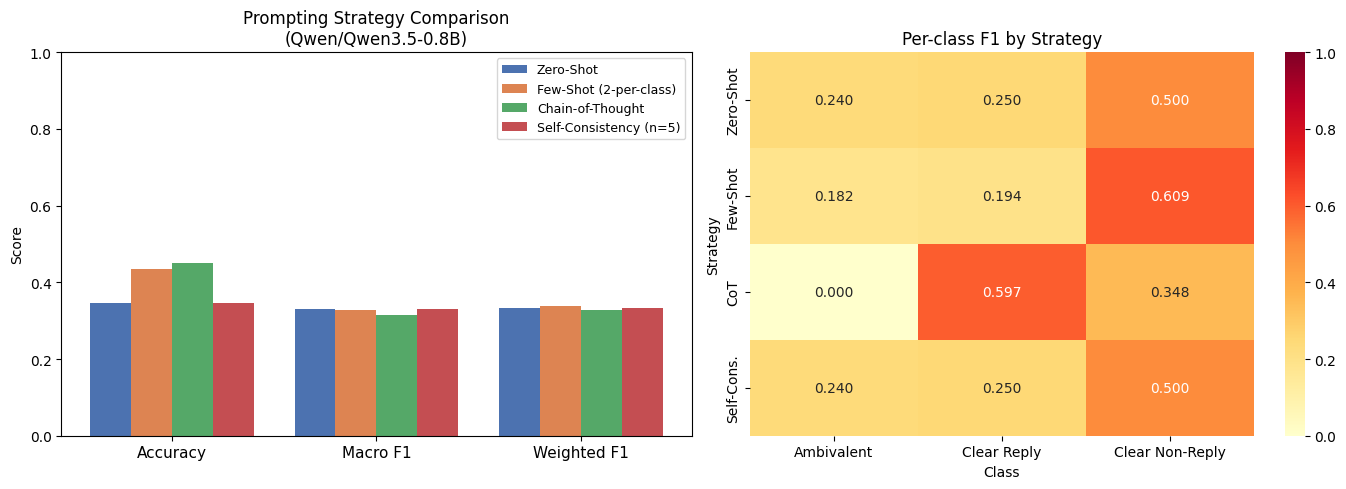

In [18]:
# Cell 15: Aggregate comparison table + chart

all_metrics = [metrics_zs, metrics_fs, metrics_cot, metrics_sc]
summary_df  = pd.DataFrame(all_metrics).set_index("strategy")
print("\n── Summary Table (Validation Set) ────────────────────────────")
print(summary_df[["accuracy","macro_f1","weighted_f1","macro_precision","macro_recall","n_invalid"]].to_string())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ["accuracy", "macro_f1", "weighted_f1"]
x = np.arange(len(metrics_to_plot))
width = 0.2
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (strategy, row) in enumerate(summary_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, vals, width, label=strategy, color=colors[i])

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(["Accuracy", "Macro F1", "Weighted F1"], fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].set_title(f"Prompting Strategy Comparison\n({MODEL_NAME})")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Score")

# Per-class F1 heatmap
report_data = {}
for name, df_res in [("Zero-Shot", val_zs), ("Few-Shot", val_fs),
                      ("CoT", val_cot), ("Self-Cons.", val_sc)]:
    valid = df_res[df_res["predicted_label"] != "Unknown"]
    rep = classification_report(valid["label"], valid["predicted_label"],
                                 target_names=LABELS, output_dict=True, zero_division=0)
    report_data[name] = {lbl: rep[lbl]["f1-score"] for lbl in LABELS}

heatmap_df = pd.DataFrame(report_data).T
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Per-class F1 by Strategy")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Strategy")

plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=150)
plt.show()

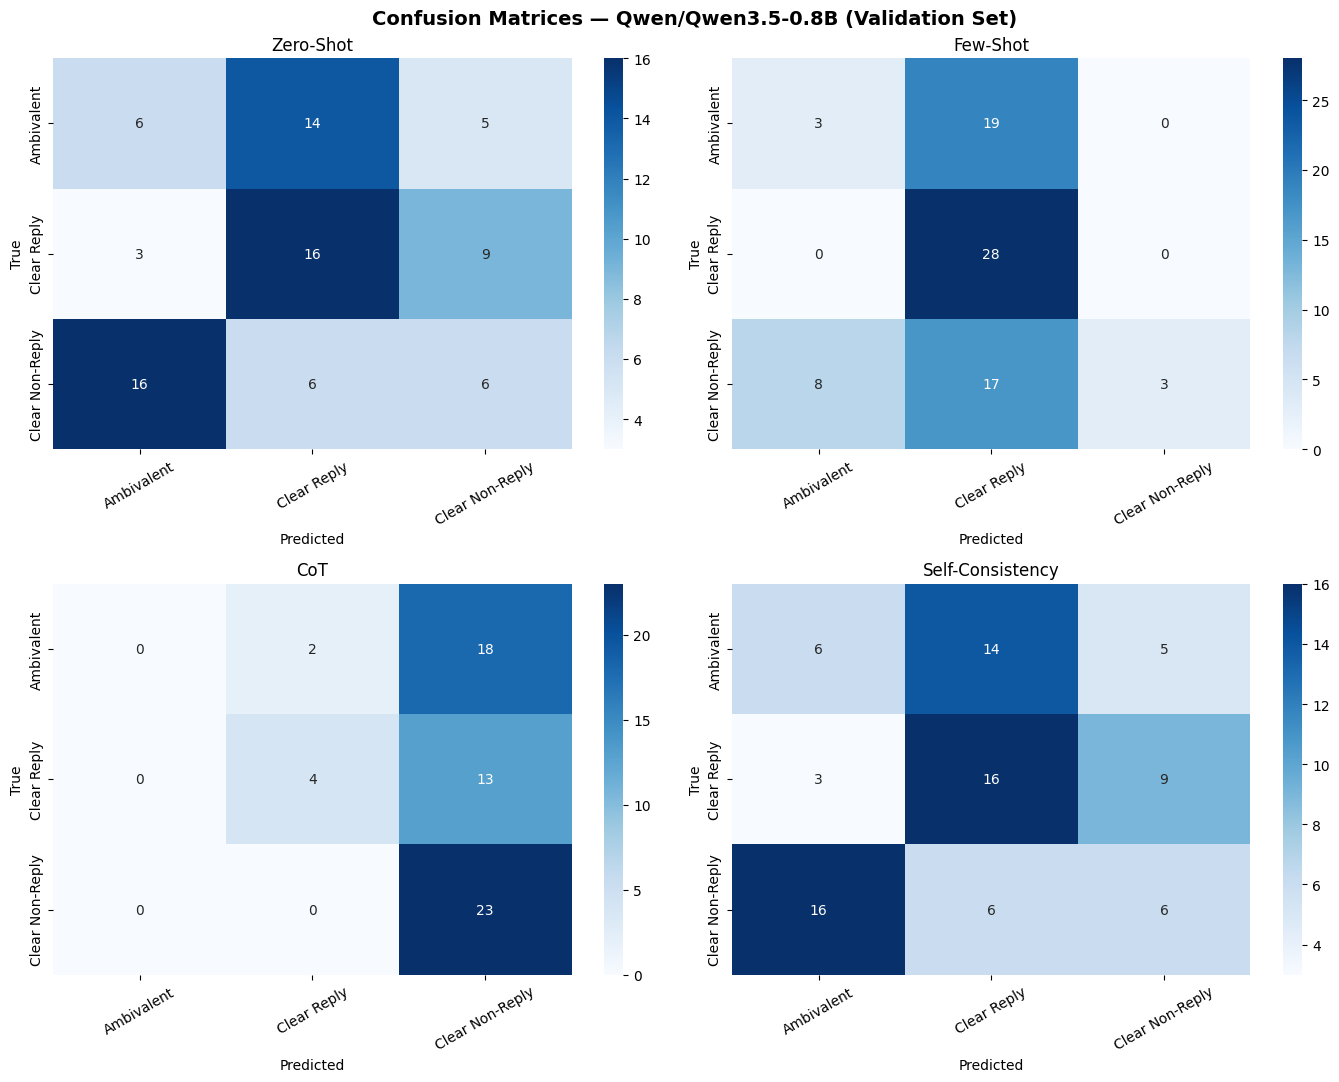

In [19]:
# Cell 16: Confusion matrices side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, df_res) in zip(axes, [("Zero-Shot", val_zs), ("Few-Shot", val_fs),
                                       ("CoT", val_cot), ("Self-Consistency", val_sc)]):
    plot_confusion_matrix(df_res, name, ax=ax)

plt.suptitle(f"Confusion Matrices — {MODEL_NAME} (Validation Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

In [20]:
# Cell 17: Error analysis

def error_analysis(df_res: pd.DataFrame, strategy_name: str, n_examples: int = 5):
    """Print misclassified examples and per-class error breakdown."""
    valid = df_res[df_res["predicted_label"] != "Unknown"].copy()
    errors = valid[valid["label"] != valid["predicted_label"]]

    print(f"\n{'='*60}")
    print(f"  Error Analysis — {strategy_name}")
    print(f"  Total errors: {len(errors)}/{len(valid)} ({100*len(errors)/len(valid):.1f}%)")
    print(f"{'='*60}")

    print("\n── Errors by True Class ──────────────────────────────────")
    print(errors["label"].value_counts().to_string())

    print("\n── Errors by (True → Predicted) ──────────────────────────")
    confusion_pairs = errors.groupby(["label", "predicted_label"]).size().sort_values(ascending=False)
    print(confusion_pairs.to_string())

    print(f"\n── {n_examples} Sample Misclassified Instances ─────────────────────")
    sample = errors.sample(min(n_examples, len(errors)), random_state=SEED)
    for _, row in sample.iterrows():
        print(f"\n  True: {row['label']}  →  Predicted: {row['predicted_label']}")
        print(f"  Q: {row['question'][:100]}")
        print(f"  A: {str(row['answer'])[:150]}")
        if "raw_output" in row:
            print(f"  Model output: {str(row['raw_output'])[:200]}")

# Run error analysis on the best strategy (update if different)
error_analysis(val_zs,  "Zero-Shot")
error_analysis(val_fs,  "Few-Shot")
error_analysis(val_cot, "Chain-of-Thought")


  Error Analysis — Zero-Shot
  Total errors: 53/81 (65.4%)

── Errors by True Class ──────────────────────────────────
label
Clear Non-Reply    22
Ambivalent         19
Clear Reply        12

── Errors by (True → Predicted) ──────────────────────────
label            predicted_label
Clear Non-Reply  Ambivalent         16
Ambivalent       Clear Reply        14
Clear Reply      Clear Non-Reply     9
Clear Non-Reply  Clear Reply         6
Ambivalent       Clear Non-Reply     5
Clear Reply      Ambivalent          3

── 5 Sample Misclassified Instances ─────────────────────

  True: Ambivalent  →  Predicted: Clear Reply
  Q: Concern about a big, urgent problem that the president worries his successor will neglect or postpon
  A: Yes. I don't think John McCain is going to neglect the war on terror, and I do think he'll be the President. Here I am interjecting myself in the '08 
  Model output: Clear Reply

  True: Clear Non-Reply  →  Predicted: Ambivalent
  Q: How serious have your threats


── Zero-Shot: Macro F1 by Answer Length ──────────
  quartile  n  macro_f1
Q1 (short) 21  0.316498
        Q2 20  0.168929
        Q3 20  0.323810
 Q4 (long) 20  0.432900

── Few-Shot: Macro F1 by Answer Length ──────────
  quartile  n  macro_f1
Q1 (short) 20  0.324786
        Q2 19  0.301994
        Q3 19  0.317460
 Q4 (long) 20  0.206897

── CoT: Macro F1 by Answer Length ──────────
  quartile  n  macro_f1
Q1 (short) 15  0.588745
        Q2 15  0.296296
        Q3 15  0.212121
 Q4 (long) 15  0.044444


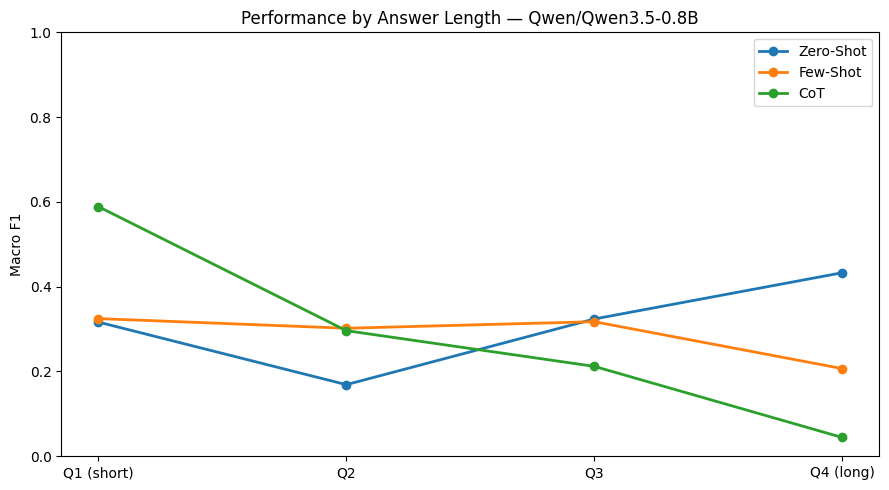

In [21]:
# Cell 18: Performance breakdown by answer length quartile

def subgroup_analysis(df_res: pd.DataFrame, strategy_name: str):
    valid = df_res[df_res["predicted_label"] != "Unknown"].copy()
    valid["answer_len"] = valid["answer"].str.split().str.len()
    valid["len_quartile"] = pd.qcut(valid["answer_len"], q=4,
                                    labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"])

    rows = []
    for q in valid["len_quartile"].cat.categories:
        sub = valid[valid["len_quartile"] == q]
        f1 = f1_score(sub["label"], sub["predicted_label"], average="macro", zero_division=0)
        rows.append({"quartile": q, "n": len(sub), "macro_f1": f1})

    sub_df = pd.DataFrame(rows)
    print(f"\n── {strategy_name}: Macro F1 by Answer Length ──────────")
    print(sub_df.to_string(index=False))
    return sub_df

sg_zs  = subgroup_analysis(val_zs,  "Zero-Shot")
sg_fs  = subgroup_analysis(val_fs,  "Few-Shot")
sg_cot = subgroup_analysis(val_cot, "CoT")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(4)
for i, (name, sg) in enumerate([("Zero-Shot", sg_zs), ("Few-Shot", sg_fs), ("CoT", sg_cot)]):
    ax.plot(x, sg["macro_f1"], marker="o", label=name, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(["Q1 (short)", "Q2", "Q3", "Q4 (long)"])
ax.set_ylabel("Macro F1")
ax.set_title(f"Performance by Answer Length — {MODEL_NAME}")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("subgroup_analysis.png", dpi=150)
plt.show()

In [22]:
# Cell 19: Identify best strategy on validation, run on test set

best_strategy_name = summary_df["macro_f1"].idxmax()
print(f"Best strategy on validation: {best_strategy_name}  "
      f"(Macro F1 = {summary_df.loc[best_strategy_name,'macro_f1']:.4f})")

# Map name back to builder
builder_map = {
    "Zero-Shot":              build_zero_shot_messages,
    "Few-Shot (2-per-class)": build_few_shot_messages_train,
    "Chain-of-Thought":       build_cot_messages,
    "Self-Consistency (n=5)": build_zero_shot_messages,   # SC handled separately
}

best_builder = builder_map[best_strategy_name]

print("\nRunning best strategy on TEST set...")
if best_strategy_name == "Self-Consistency (n=5)":
    test_results = run_self_consistency(test_df, best_builder, n_samples=N_SAMPLES)
else:
    test_results = run_inference(test_df, best_builder,
                                  max_new_tokens=30 if "CoT" not in best_strategy_name else MAX_NEW_TOKENS)

print(f"\nTest predictions sample:\n{test_results['predicted_label'].value_counts()}")

Best strategy on validation: Zero-Shot  (Macro F1 = 0.3300)

Running best strategy on TEST set...
  30/308 done | invalid: 1
  60/308 done | invalid: 4
  90/308 done | invalid: 4
  120/308 done | invalid: 6
  150/308 done | invalid: 9
  180/308 done | invalid: 9
  210/308 done | invalid: 11
  240/308 done | invalid: 13
  270/308 done | invalid: 16
  300/308 done | invalid: 17
Done. Invalid: 17/308 (5.5%)

Test predictions sample:
predicted_label
Clear Reply        178
Clear Non-Reply     68
Ambivalent          45
Unknown             17
Name: count, dtype: int64


In [23]:
# Cell 20: Resolve unknown labels & write submission CSV

# Fallback for unparsed outputs: assign majority class in train
MAJORITY_CLASS = train_df["label"].value_counts().idxmax()
print(f"Majority class fallback: {MAJORITY_CLASS}")

final_labels = test_results["predicted_label"].replace("Unknown", MAJORITY_CLASS)

submission = pd.DataFrame({
    "Id":    test_df["id"] if "id" in test_df.columns else range(len(test_df)),
    "Predicted": final_labels,
})

submission.to_csv("submission.csv", index=False)
print("Saved: submission.csv")
print(submission["Predicted"].value_counts())
print(submission.head(10))

Majority class fallback: Ambivalent
Saved: submission.csv
Predicted
Clear Reply        178
Clear Non-Reply     68
Ambivalent          62
Name: count, dtype: int64
   Id        Predicted
0   0      Clear Reply
1   1      Clear Reply
2   2      Clear Reply
3   3      Clear Reply
4   4       Ambivalent
5   5      Clear Reply
6   6      Clear Reply
7   7      Clear Reply
8   8      Clear Reply
9   9  Clear Non-Reply


In [24]:
# Cell 21: Final summary for report

print("=" * 65)
print(f"  MODEL : {MODEL_NAME}")
print("  DATASET : CLARITY (political Q&A)")
print("  SPLIT evaluated on : Validation set")
print("=" * 65)
print(summary_df[["accuracy","macro_f1","weighted_f1","n_invalid"]].to_string())
print(f"\n  Best strategy : {best_strategy_name}")
print(f"  Best Macro F1 : {summary_df['macro_f1'].max():.4f}")
print("=" * 65)
print("\nFiles saved:")
print("  submission.csv")
print("  label_distribution.png")
print("  length_distribution.png")
print("  strategy_comparison.png")
print("  confusion_matrices.png")
print("  subgroup_analysis.png")

  MODEL : Qwen/Qwen3.5-0.8B
  DATASET : CLARITY (political Q&A)
  SPLIT evaluated on : Validation set
                        accuracy  macro_f1  weighted_f1  n_invalid
strategy                                                          
Zero-Shot               0.345679  0.330000     0.333333          9
Few-Shot (2-per-class)  0.435897  0.328021     0.339267         12
Chain-of-Thought        0.450000  0.315076     0.327555         30
Self-Consistency (n=5)  0.345679  0.330000     0.333333          9

  Best strategy : Zero-Shot
  Best Macro F1 : 0.3300

Files saved:
  submission.csv
  label_distribution.png
  length_distribution.png
  strategy_comparison.png
  confusion_matrices.png
  subgroup_analysis.png
